# Depth vs execution time (current algorithm)

Functional benchmark of `SearchEngine.alpha_beta_search` on a fixed mid-game board.
Each depth is measured over a large number of repetitions and reported in **microseconds**
so that small per-depth differences are visible on the chart.

> **Note:** `depth` is currently accepted but not yet consumed by the search stub — the measured cost is the terminal/evaluation pass plus candidate generation, so the curve is expected to be flat. Re-run this notebook once the recursive search lands to capture the real growth curve.

In [1]:
import time

from defines import Defines, StoneMove
from tools import init_board
from search_engine import SearchEngine

DEPTHS = list(range(1, 10))
REPEATS = 2000

In [2]:
def create_benchmark_board():
    board = [[0] * Defines.GRID_NUM for _ in range(Defines.GRID_NUM)]
    init_board(board)
    stones = [
        (10, 10), (11, 10), (9, 11), (11, 9), (8, 12),
        (12, 8), (9, 9), (12, 11), (10, 12), (13, 9),
    ]
    for i, (x, y) in enumerate(stones):
        board[x][y] = Defines.BLACK if i % 2 == 0 else Defines.WHITE
    return board

def make_last_move(x, y):
    move = StoneMove()
    move.positions[0].x = move.positions[1].x = x
    move.positions[0].y = move.positions[1].y = y
    return move

def measure_depth(depth):
    board = create_benchmark_board()
    engine = SearchEngine()
    pre_move = make_last_move(13, 9)
    samples = []
    for _ in range(REPEATS):
        engine.before_search(board, Defines.BLACK, depth)
        best_move = StoneMove()
        start = time.perf_counter()
        engine.alpha_beta_search(depth, Defines.MININT, Defines.MAXINT, Defines.BLACK, best_move, pre_move)
        samples.append(time.perf_counter() - start)
    return min(samples) * 1_000_000

In [3]:
times_us = [measure_depth(depth) for depth in DEPTHS]

print("| depth | min time (µs) |")
print("|-------|--------------|")
for depth, us in zip(DEPTHS, times_us):
    print(f"| {depth} | {us:.1f} |")

| depth | min time (µs) |
|-------|--------------|
| 1 | 178.0 |
| 2 | 178.5 |
| 3 | 178.5 |
| 4 | 177.8 |
| 5 | 178.2 |
| 6 | 178.0 |
| 7 | 177.7 |
| 8 | 179.4 |
| 9 | 177.7 |


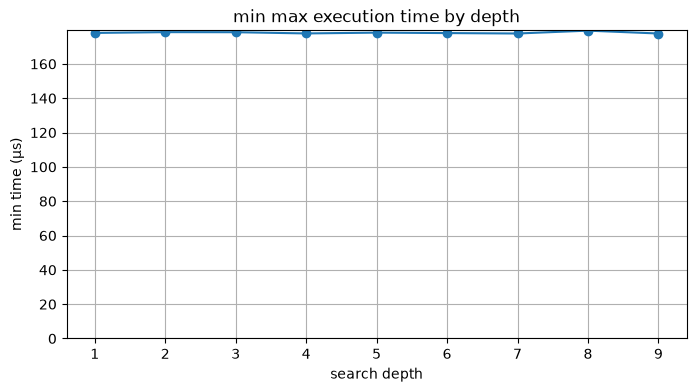

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(DEPTHS, times_us, marker="o", color="tab:blue")
ax.set_xlabel("search depth")
ax.set_ylabel("min time (µs)")
ax.set_title("min max execution time by depth")
ax.set_xticks(DEPTHS)
ax.set_ylim(bottom=0)
ax.grid(True)
plt.show()

## Reading the results

- Times are reported in microseconds, taking the **minimum** of `REPEATS = 2000` samples per depth (the `timeit` approach): the minimum filters out OS scheduling noise, so differences of a few µs between depths are real rather than jitter.
- With the current stub the cost is flat at every depth: the evaluation sweep plus candidate generation dominate, and `depth` is not consumed yet.
- Once the recursive alpha-beta search is implemented, the same notebook will show the branching cost — expected to grow roughly with `MAX_CANDIDATE_MOVES^depth`, moderated by pruning. At that point the µs scale will make the early depths' cost readable while the log-style growth dominates the chart.